# Visualization of Euclid VIS Image and DESI Spectrum

This notebook loads and visualizes the outputs generated by the `generate_euclid_vis.py` script.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import (astropy_mpl_style, ZScaleInterval, 
                                   LogStretch, ImageNormalize)
import os

plt.style.use(astropy_mpl_style)

In [12]:
# Define paths
data_dir = '/Users/marchuertascompany/Documents/data/EUCLID/syntesizer'
image_path = os.path.join(data_dir, 'euclid_vis_96768.fits')
spectrum_path = os.path.join(data_dir, 'subhalo_96768_full_spectrum.fits')

## 1. Euclid VIS Image

We use a log-stretch normalization to better see the galaxy structure.

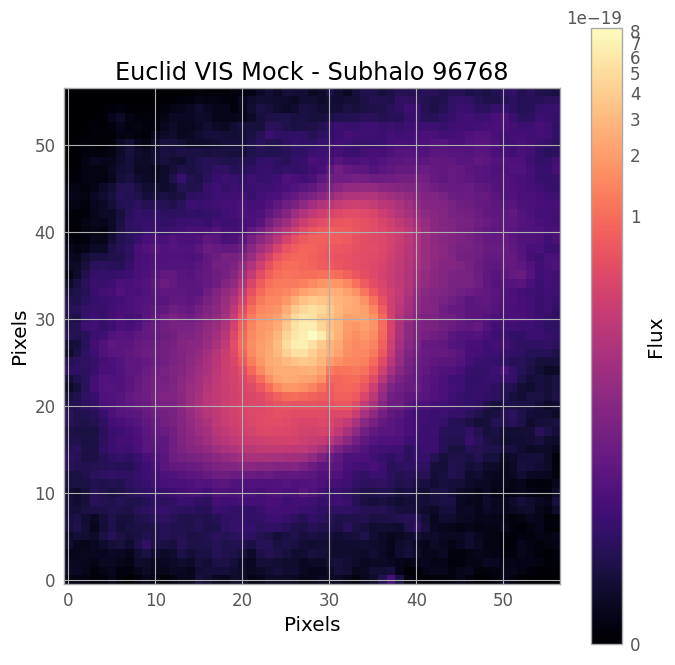

In [4]:
if os.path.exists(image_path):
    with fits.open(image_path) as hdul:
        data = hdul[0].data
        header = hdul[0].header
        
    norm = ImageNormalize(data, stretch=LogStretch())
    
    plt.figure(figsize=(8, 8))
    plt.imshow(data, cmap='magma', norm=norm, origin='lower')
    plt.colorbar(label='Flux')
    plt.title(f"Euclid VIS Mock - {header.get('OBJECT', 'Galaxy')}")
    plt.xlabel('Pixels')
    plt.ylabel('Pixels')
    plt.show()
else:
    print(f"Image not found at {image_path}")

## 2. DESI Mock Spectrum

Plotting the convolved and resampled spectrum.

In [13]:
if os.path.exists(spectrum_path):
    with fits.open(spectrum_path) as hdul:
        spec_data = hdul[1].data
        spec_header = hdul[1].header
        
    plt.figure(figsize=(12, 5))
    plt.plot(spec_data['wavelength'], spec_data['flux'], color='black', lw=0.5)
    
    # Highlight some common lines if they are in range
    lines = {
        'H-alpha': 6564.6,
        '[OIII]': 5008.2,
        'H-beta': 4862.7,
        '[OII]': 3728.5
    }
    
    z = spec_header.get('REDSHIFT', 0.0)
    for name, lam in lines.items():
        obs_lam = lam * (1 + z)
        if spec_data['wavelength'].min() < obs_lam < spec_data['wavelength'].max():
            plt.axvline(obs_lam, color='red', linestyle='--', alpha=0.3)
            plt.text(obs_lam, plt.ylim()[1]*0.9, name, color='red', rotation=90, verticalalignment='top')

    plt.title(f"DESI Mock Spectrum (z={z:.3f})")
    plt.xlabel('Wavelength [Angstrom]')
    plt.ylabel('Flux [erg/s/cm^2/Hz]')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print(f"Spectrum not found at {spectrum_path}")

KeyError: "Key 'flux' does not exist."

<Figure size 1200x500 with 0 Axes>

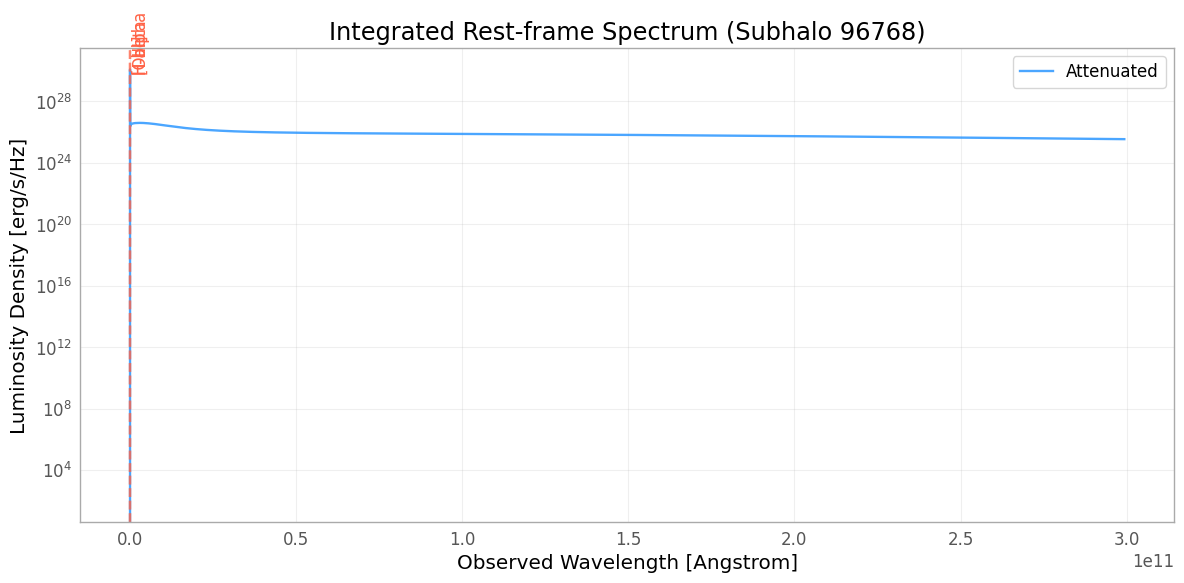

In [15]:
diag_spec_path = os.path.join(data_dir, 'subhalo_96768_full_spectrum.fits')

if os.path.exists(diag_spec_path):
    with fits.open(diag_spec_path) as hdul:
        data = hdul[1].data
        header = hdul[1].header
        
    plt.figure(figsize=(12, 6))
    
    # Robustly handle both rest-frame (L_nu) and observed-frame (F_nu) formats
    if 'WAVELENGTH' in data.names:
        # Old/Diagnostic format (Uppercase columns, Rest-frame luminosity)
        lam = data['WAVELENGTH']
        flux = data['LNU_ATTENUATED']
        ylabel = 'Luminosity Density [erg/s/Hz]'
        z = header.get('REDSHIFT', 0.0)
        title = f"Integrated Rest-frame Spectrum (Subhalo {header.get('SUBHALO')})"
        lam_plot = lam * (1 + z) # Plot in observed frame for consistency
    else:
        # Standardized/DESI format (Lowercase columns, Observed-frame flux)
        lam_plot = data['wavelength']
        flux = data['flux']
        ylabel = 'Flux [erg/s/cm^2/Hz]'
        z = header.get('REDSHIFT', 0.0)
        title = f"Integrated Observed-frame Spectrum (Subhalo {header.get('SUBHALO')})"
        
    plt.plot(lam_plot, flux, color='dodgerblue', label='Attenuated', alpha=0.8)
    
    # Highlighting lines
    lines = {'H-alpha': 6564.6, '[OIII]': 5008.2, 'H-beta': 4862.7}
    for name, line_lam in lines.items():
        obs_lam = line_lam * (1 + z)
        if lam_plot.min() < obs_lam < lam_plot.max():
            plt.axvline(obs_lam, color='tomato', linestyle='--', alpha=0.4)
            plt.text(obs_lam, plt.ylim()[1]*0.9, name, color='tomato', rotation=90)

    plt.title(title)
    plt.xlabel('Observed Wavelength [Angstrom]')
    plt.ylabel(ylabel)
    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print(f"Diagnostic spectrum not found at {diag_spec_path}")

In [18]:
import os
from astropy.io import fits

# Point this to the file you generated earlier
diag_spec_path = os.path.join(data_dir, 'subhalo_96768_full_spectrum.fits')

if os.path.exists(diag_spec_path):
    with fits.open(diag_spec_path) as hdul:
        data = hdul[1].data
        header = hdul[1].header
        
        print(f"--- FITS Columns ---\n{data.names}")
        
        print("\n--- First 5 Wavelength entries ---")
        # Try both case variants
        wcol = 'wavelength' if 'wavelength' in data.names else 'WAVELENGTH'
        print(f"{wcol}: {data[wcol][:5]}")
        
        print("\n--- First 5 Flux/Luminosity entries ---")
        fcol = 'flux' if 'flux' in data.names else ('LNU_ATTENUATED' if 'LNU_ATTENUATED' in data.names else data.names[1])
        print(f"{fcol}: {data[fcol][:5]}")
        
        # Check range for plotting
        x = data[wcol]
        print(f"\nX-axis Range (min, max): {x.min():.2e}, {x.max():.2e}")
else:
    print(f"File not found at {diag_spec_path}")

--- FITS Columns ---
['WAVELENGTH', 'LNU_INTRINSIC', 'LNU_ATTENUATED']

--- First 5 Wavelength entries ---
WAVELENGTH: [0.00012966 0.0001336  0.00013766 0.00014184 0.00014615]

--- First 5 Flux/Luminosity entries ---
LNU_ATTENUATED: [0. 0. 0. 0. 0.]

X-axis Range (min, max): 1.30e-04, 2.99e+11


In [20]:
import os
import matplotlib.pyplot as plt
from astropy.io import fits

diag_spec_path = os.path.join(data_dir, 'subhalo_96768_full_spectrum.fits')

if os.path.exists(diag_spec_path):
    with fits.open(diag_spec_path) as hdul:
        data = hdul[1].data
        header = hdul[1].header
        
    z = header.get('REDSHIFT', 0.0)
    plt.figure(figsize=(12, 5))
    
    # Standard format: lowercase 'wavelength' and 'flux'
    plt.plot(data['wavelength'], data['flux'], color='black', lw=0.7, label='Full Integrated Spectrum')
    
    # Highlighting lines
    lines = {'H-alpha': 6564.6, '[OIII]': 5008.2, 'H-beta': 4862.7}
    for name, line_lam in lines.items():
        obs_lam = line_lam * (1 + z)
        if data['wavelength'].min() < obs_lam < data['wavelength'].max():
            plt.axvline(obs_lam, color='red', linestyle='--', alpha=0.3)
            plt.text(obs_lam, plt.ylim()[1]*0.8, name, color='red', rotation=90)

    plt.title(f"Subhalo {header.get('SUBHALO')} Integrated Spectrum (z={z:.3f})")
    plt.xlabel('Observed Wavelength [Angstrom]')
    plt.ylabel('Flux [erg/s/cm^2/Hz]')
    plt.yscale('log')
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()
else:
    print(f"File not found at {diag_spec_path}")

KeyError: "Key 'flux' does not exist."

<Figure size 1200x500 with 0 Axes>

Viewing Subhalo 96768 (z=0.000)


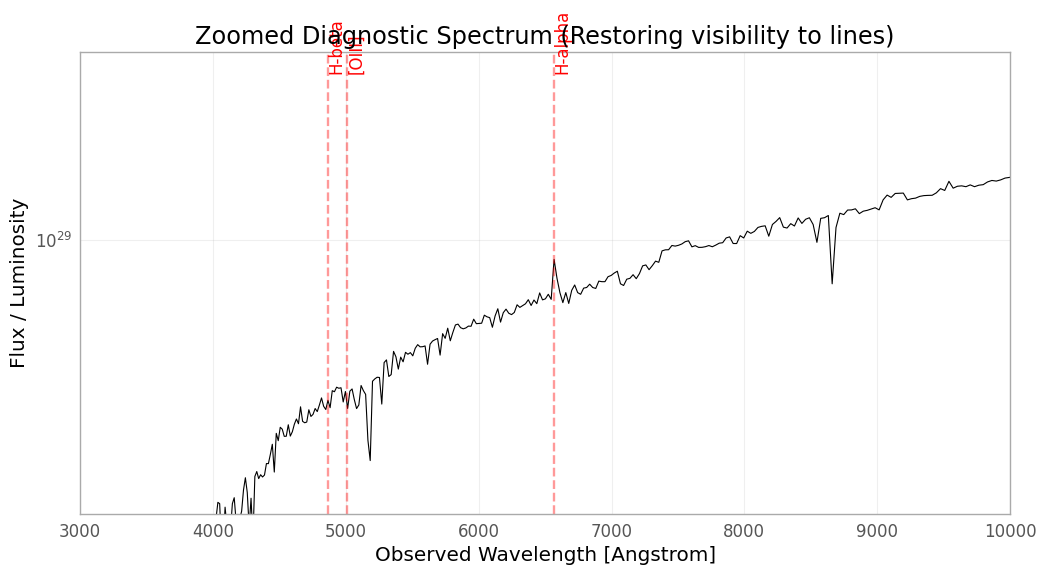

H-alpha observed peak check: 6567.8 A, Flux=8.90e+28


In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Use the file you already generated
diag_spec_path = os.path.join(data_dir, 'subhalo_96768_full_spectrum.fits')

if os.path.exists(diag_spec_path):
    with fits.open(diag_spec_path) as hdul:
        data = hdul[1].data
        header = hdul[1].header
        
    # 1. Identify columns (handles both uppercase and lowercase)
    x_name = 'WAVELENGTH' if 'WAVELENGTH' in data.names else 'wavelength'
    y_name = 'LNU_ATTENUATED' if 'LNU_ATTENUATED' in data.names else 'flux'
    
    x = data[x_name]
    y = data[y_name]
    z = header.get('REDSHIFT', 0.0)
    
    print(f"Viewing Subhalo {header.get('SUBHALO')} (z={z:.3f})")

    # 2. Plot
    plt.figure(figsize=(12, 6))
    plt.plot(x, y, color='black', lw=0.8)
    
    # 3. ZOOM IN to the Optical Range (where the lines are)
    # We zoom to 3000-10000 Angstroms to avoid the 10^11 radio noise
    plt.xlim(3000 * (1+z), 10000 * (1+z))
    plt.ylim(2e28, 3e29)
    
    # Highlight lines
    lines = {'H-alpha': 6564.6, '[OIII]': 5008.2, 'H-beta': 4862.7}
    for name, lam in lines.items():
        obs_lam = lam * (1 + z)
        plt.axvline(obs_lam, color='red', linestyle='--', alpha=0.4)
        plt.text(obs_lam, plt.gca().get_ylim()[1]*0.9, name, color='red', rotation=90)

    plt.title(f"Zoomed Diagnostic Spectrum (Restoring visibility to lines)")
    plt.xlabel('Observed Wavelength [Angstrom]')
    plt.ylabel('Flux / Luminosity')
    plt.yscale('log')
    plt.grid(True, alpha=0.2)
    plt.show()
    
    # Check if lines are detected numerically if you still can't see them
    ha_obs = 6564.6 * (1+z)
    idx = np.argmin(np.abs(x - ha_obs))
    print(f"H-alpha observed peak check: {x[idx]:.1f} A, Flux={y[idx]:.2e}")

else:
    print(f"File not found at {diag_spec_path}")

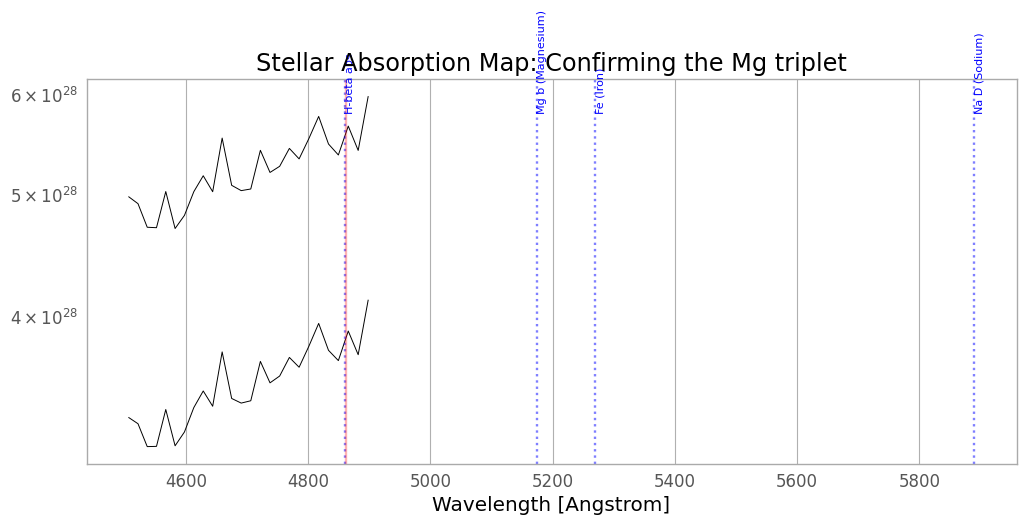

In [36]:
plt.figure(figsize=(12, 5))
mask = (data['WAVELENGTH'] > 4500) & (data['WAVELENGTH'] < 4900)
plt.plot(data['WAVELENGTH'][mask], data['LNU_ATTENUATED'][mask], color='black', lw=0.7)
plt.plot(data['WAVELENGTH'][mask], data['LNU_INTRINSIC'][mask], color='black', lw=0.7)


# Label the absorptions
absorptions = {
    'H-beta abs': 4861,
    'Mg b (Magnesium)': 5175,
    'Na D (Sodium)': 5890,
    'Fe (Iron)': 5270
}

for name, lam in absorptions.items():
    plt.axvline(lam, color='blue', linestyle=':', alpha=0.5)
    plt.text(lam, plt.ylim()[1]*0.95, name, color='blue', rotation=90, fontsize=8)

plt.axvline(4862.7, color='red', alpha=0.3, label='H-beta rest')
plt.title("Stellar Absorption Map: Confirming the Mg triplet")
plt.xlabel('Wavelength [Angstrom]')
plt.yscale('log')
plt.show()

/Users/marchuertascompany/soft/miniforge3/envs/Denario_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/marchuertascompany/soft/miniforge3/envs/Denario_env/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


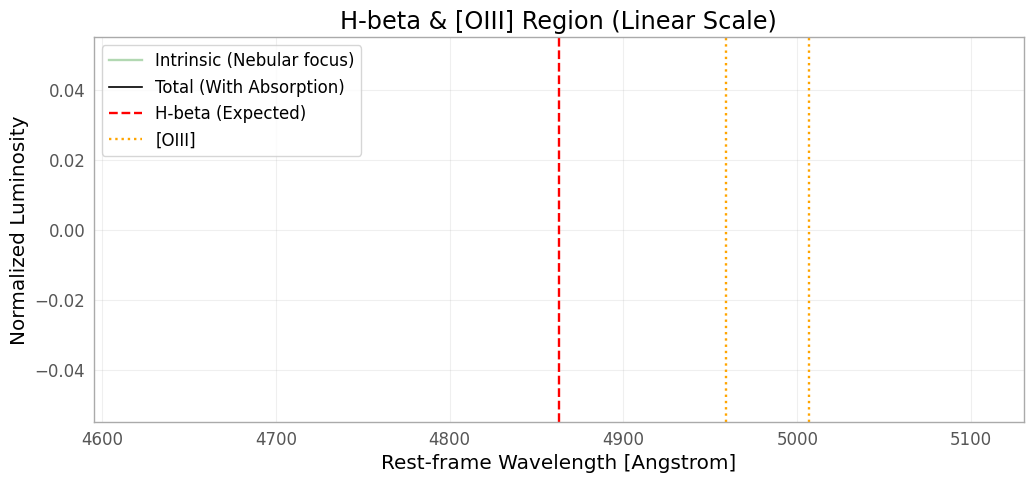

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

diag_spec_path = os.path.join(data_dir, 'subhalo_96768_full_spectrum.fits')

if os.path.exists(diag_spec_path):
    with fits.open(diag_spec_path) as hdul:
        data = hdul[1].data
        
    x = data['WAVELENGTH'] if 'WAVELENGTH' in data.names else data['wavelength']
    y_att = data['LNU_ATTENUATED'] if 'LNU_ATTENUATED' in data.names else data['flux']
    y_int = data['LNU_INTRINSIC'] if 'LNU_INTRINSIC' in data.names else None

    # Fix x-axis if it's still in the wrong unit (Frequency)
    if np.max(x) > 1e11:
        c = 2.9979e18 # Angstrom/s
        x = c / x
        idx = np.argsort(x)
        x = x[idx]; y_att = y_att[idx]
        if y_int is not None: y_int = y_int[idx]

    # Focus ON H-beta region (4861 A)
    plt.figure(figsize=(12, 5))
    mask = (x > 4700) & (x < 5050)
    
    # Normalize by the median in this window to make it easier to see
    norm = np.median(y_att[mask])
    
    if y_int is not None:
        plt.plot(x[mask], y_int[mask]/norm, label='Intrinsic (Nebular focus)', color='green', alpha=0.3)
    
    plt.plot(x[mask], y_att[mask]/norm, label='Total (With Absorption)', color='black', lw=1.2)
    
    # Highlight the Line Locations
    plt.axvline(4862.7, color='red', linestyle='--', label='H-beta (Expected)')
    plt.axvline(4959.0, color='orange', linestyle=':', label='[OIII]')
    plt.axvline(5006.8, color='orange', linestyle=':')

    plt.title("H-beta & [OIII] Region (Linear Scale)")
    plt.xlabel('Rest-frame Wavelength [Angstrom]')
    plt.ylabel('Normalized Luminosity')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

else:
    print(f"File not found at {diag_spec_path}")

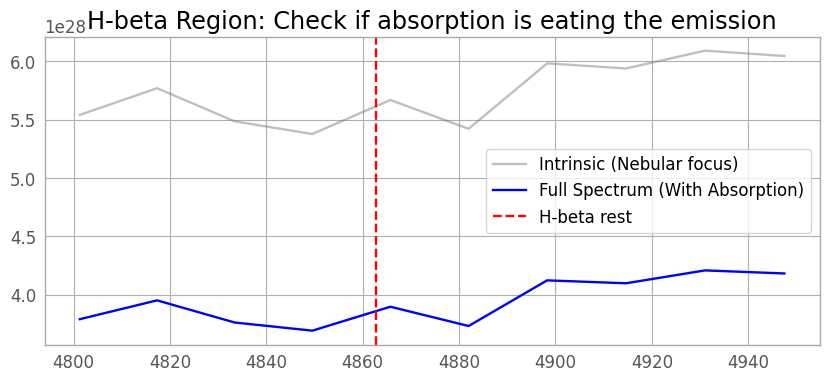

H-beta value in file: 3.90e+28


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

diag_spec_path = os.path.join(data_dir, 'subhalo_96768_full_spectrum.fits')

if os.path.exists(diag_spec_path):
    with fits.open(diag_spec_path) as hdul:
        data = hdul[1].data
        
    x = data['WAVELENGTH'] if 'WAVELENGTH' in data.names else data['wavelength']
    y_att = data['LNU_ATTENUATED'] if 'LNU_ATTENUATED' in data.names else data['flux']
    y_int = data['LNU_INTRINSIC'] if 'LNU_INTRINSIC' in data.names else None

    # Focus on H-beta region (4861 A)
    plt.figure(figsize=(10, 4))
    mask = (x > 4800) & (x < 4950)
    
    if y_int is not None:
        plt.plot(x[mask], y_int[mask], label='Intrinsic (Nebular focus)', color='gray', alpha=0.5)
    
    plt.plot(x[mask], y_att[mask], label='Full Spectrum (With Absorption)', color='blue')
    plt.axvline(4862.7, color='red', linestyle='--', label='H-beta rest')
    
    plt.title("H-beta Region: Check if absorption is eating the emission")
    plt.legend()
    plt.show()

    # Numerical Check
    hb_idx = np.argmin(np.abs(x - 4862.7))
    print(f"H-beta value in file: {y_att[hb_idx]:.2e}")

In [47]:
print(25.25-10*np.log10(1.1)-0.1-0.05)



dl = 1.1*3000*0.1
#print(dl)

#print(5*np.log10(dl))

print(-18.5+5*np.log10(dl)+25+2.5*np.log10(2*np.pi*0.5**2)-10*np.log10(1.1))

faint_mag = 20-5*np.log10(dl)+5-0.1-0.05
#print(faint_mag)

bright_mag = 13-5*np.log10(dl)+5-0.1-0.05
#print(bright_mag)

#print(13-12.59-25-0.10-0.05)

24.686073148417748
19.168942540382567
